> # **RNN - (Recurrent Neural Network)**
- process sequential data by retaining information from previous steps.
- They are especially effective for tasks where context and order matter.
- Designed for sequential and temporal data
- Maintains memory of past inputs
> - **Unlike traditional deep neural networks where each dense layer has distinct weight matrices. RNNs use shared weights across time steps, allowing them to remember information over sequences.**

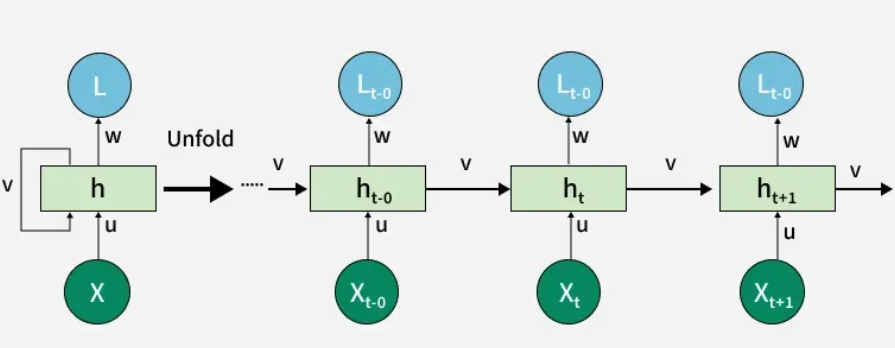


> ## **A simple text classification model using SimpleRNN in Keras (running on TensorFlow backend).**


In [2]:
# import the libraries
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

In [3]:
# load the dataset
vocab_size = 10000
max_length = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words = vocab_size)

x_train = pad_sequences(x_train, maxlen = max_length)
x_test = pad_sequences(x_test, maxlen = max_length)

print(type(x_train))
print(type(y_train))
print(x_train.shape)
print(y_train.shape)
print('x_train:', x_train[0:2])
print('x_test :', x_test[0:2])
print('y_train :', y_train[0:2])
print('y_test :', y_test[0:2])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(25000, 200)
(25000,)
x_train: [[   5   25  100   43  838  112   50  670    2    9   35  480  284    5
   150    4  172  112  167    2  336  385   39    4  172 4536 1111   17
   546   38   13  447    4  192   50   16    6  147 2025   19   14   22
     4 1920 4613  469    4   22   71   87   12   16   43  530   38   76
    15   13 1247    4   22   17  515   17   12   16  626   18    2    5
    62  386   12    8  316    8  106    5    4 2223 5244   16  480   66
  3785   33    4  130   12   16   38  619    5   25  124   51   36  135
    48   25 1415   33    6   22   12  215   28   77   52    5   14  407
    16   82    2    8    4  107  117 5952   15  256    4    2    7 3766
     5  723   36   71   43  530  476   26  400  317   46    7    4    2
  1029   13  104   88    4  381   15  297   98   32 2071   56   26  141
     6  194 7486   18    4  226   22   21  134  476   26  480    5  144
    30

> ## Embedding Layer - Embedding(input_dim=vocab_size, output_dim=128)

Purpose:

Converts word indices → dense vectors

Learns semantic representation

Output shape: (batch_size, sequence_length, 128)

> ## SimpleRNN(64)

Purpose:

Processes sequence step by step

Maintains hidden state

Learns temporal dependencies

64 = number of hidden units.

Output shape: (batch_size, 64)

> ## Dense(1, activation='sigmoid')

Purpose:

Final classification layer

Outputs probability (0–1)

In [28]:
# build the model
model = Sequential()

model.add(Embedding(input_dim = vocab_size, output_dim = 128, input_length=max_length))                            # Output shape: (batch_size, sequence_length, 128)

model.add(SimpleRNN(64))                                                                  # Output shape: (batch_size, 64)

model.add(Dense(1, activation = 'sigmoid'))                                               # probability (0–1)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_6 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

> ## Keras needs input shape to compute:

Embedding parameters = vocab_size × embedding_dim

RNN parameters = (input_dim + hidden_units) × hidden_units + bias

Dense parameters = hidden_units × output_units + bias

But it doesn’t know input shape yet.

In [29]:
# compile model
model.compile(optimizer='adam', loss = 'binary_crossentropy', metrics=['accuracy'])

In [30]:
# train model
history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.2)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 109ms/step - accuracy: 0.5658 - loss: 0.6730 - val_accuracy: 0.7358 - val_loss: 0.5307
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 98ms/step - accuracy: 0.7353 - loss: 0.5252 - val_accuracy: 0.7272 - val_loss: 0.5488
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 100ms/step - accuracy: 0.8827 - loss: 0.3005 - val_accuracy: 0.7422 - val_loss: 0.5839
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 107ms/step - accuracy: 0.9772 - loss: 0.0811 - val_accuracy: 0.7346 - val_loss: 0.7424
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 101ms/step - accuracy: 0.9968 - loss: 0.0192 - val_accuracy: 0.7402 - val_loss: 0.8510


In [31]:
loss, accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.7410 - loss: 0.8652
Test Accuracy: 0.7415599822998047


> # **Deep RNN - Multiple RNN layers stacked on top of each other.**
- Input → RNN → RNN → RNN → Output
- Why Use Deep RNN?
    1. Captures complex sequence dependencies
    2. Learns hierarchical representations
    3. Better feature extraction for text classification

In [19]:
# Deep RNN
model = Sequential([
    Embedding(input_dim = vocab_size, output_dim = 128, input_length = max_length),

    # First RNN layer (must return sequences)
    SimpleRNN(64, return_sequences = True),

    # Second RNN layer (must return sequences)
    SimpleRNN(32, return_sequences= True),

    #Third RNN layer
    SimpleRNN(16),

    # Output layer
    Dense(1, activation = 'sigmoid')
])

model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_12 (SimpleRNN)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_13 (SimpleRNN)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_14 (SimpleRNN)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
Drnn_history = model.fit(x_train, y_train, epochs = 5, batch_size = 64, validation_split = 0.2)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 56s 168ms/step - accuracy: 0.5348 - loss: 0.6932 - val_accuracy: 0.7036 - val_loss: 0.5680
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 165ms/step - accuracy: 0.7706 - loss: 0.4869 - val_accuracy: 0.8038 - val_loss: 0.4533
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 164ms/step - accuracy: 0.8131 - loss: 0.4212 - val_accuracy: 0.7876 - val_loss: 0.4613
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 52s 167ms/step - accuracy: 0.8680 - loss: 0.3276 - val_accuracy: 0.8210 - val_loss: 0.4054
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 56s 179ms/step - accuracy: 0.9063 - loss: 0.2525 - val_accuracy: 0.8056 - val_loss: 0.4748


> ## let's analysis these score
- val_loss

    - Loss on validation set.
    - Important for detecting overfitting.

- Model Learning

    - Training accuracy keeps increasing.
    - Training loss keeps decreasing.

- How To Detect Overfitting

    - If -----> Training accuracy ↑
    - Validation accuracy ↓
    - Validation loss ↑
    - → Overfitting
    - That’s happening slightly at Epoch 5. means --> Model memorizing training data.

- What Should You Do?

    - Use EarlyStopping
    - Add Dropout layer
    - Reduce model complexity
    - Train fewer epochs

In [38]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(patience=2, restore_best_weights=True)

In [21]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_12 (SimpleRNN)       │ (None, 200, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_13 (SimpleRNN)       │ (None, 200, 32)        │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_14 (SimpleRNN)       │ (None, 16)             │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,888,773 (14.83 MB)

 Trainable params: 1,296,257 (4.94 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,592,516 (9.89 MB)

In [22]:
loss, accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.7967 - loss: 0.4866
Test Accuracy: 0.7972800135612488


In [32]:
print(Drnn_history.history.values())
print(Drnn_history.history.keys())
accuracy, loss, val_accuracy, val_loss = Drnn_history.history.values()

dict_values([[0.5908499956130981, 0.7778499722480774, 0.8069000244140625, 0.8677999973297119, 0.8902000188827515], [0.6560201048851013, 0.47509634494781494, 0.43583980202674866, 0.32318755984306335, 0.2798781394958496], [0.7035999894142151, 0.8037999868392944, 0.7875999808311462, 0.8209999799728394, 0.8055999875068665], [0.5679566264152527, 0.45327866077423096, 0.46132275462150574, 0.4054323434829712, 0.474776029586792]])
dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


> ## How To Plot Learning Curves

> ## How To Read the Curves
```
1. Case A — Good Fit

- Training accuracy ↑

- Validation accuracy ↑

- Both stabilize near each other

- Loss decreases smoothly

Meaning:

Model generalizes well.
```
```

2. Case B — Overfitting

- Training accuracy keeps increasing

- Validation accuracy stops increasing or decreases

- Validation loss starts increasing

- This is what your training showed at Epoch 5.

Meaning:

Model memorizing training data.
```
```

3. Case C — Underfitting

Pattern:

Training accuracy low

Validation accuracy low

Loss high for both

Meaning:
Model too simple or not trained enough.
```
```

4. Case D — High Variance / Unstable Training


- Loss jumps up and down

- Accuracy fluctuates heavily

Meaning:
Learning rate too high or batch size too small.
```

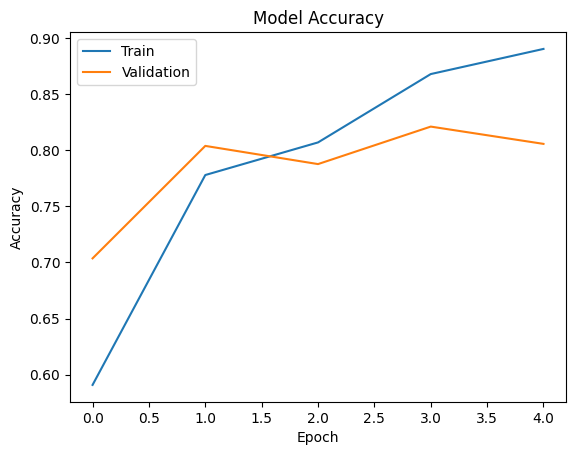

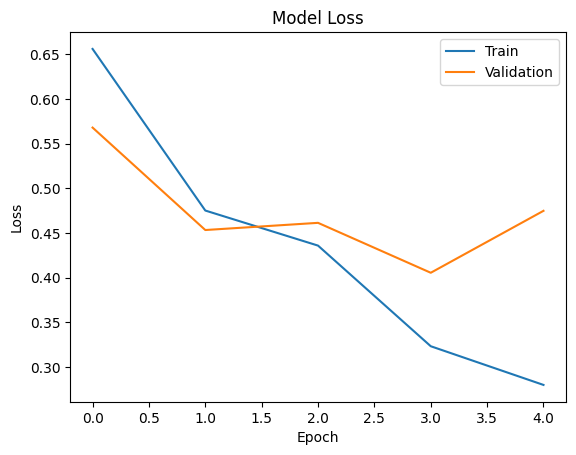

In [40]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure()
plt.plot(Drnn_history.history['accuracy'])
plt.plot(Drnn_history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

# Loss
plt.figure()
plt.plot(Drnn_history.history['loss'])
plt.plot(Drnn_history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

> ## What To Do After Seeing Curves

If overfitting:

- Add Dropout layer

- Reduce RNN units

- Use EarlyStopping

- Add regularization

- Train fewer epochs

If underfitting:

- Increase model capacity

- Train longer

- Improve embeddings

> ## **For Binary Classification**

In [33]:
# general probabilities
y_prob = model.predict(x_test)
print('y_prob :', y_prob)

782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step
y_prob : [[0.11496241]
 [0.9750564 ]
 [0.794034  ]
 ...
 [0.071446  ]
 [0.03451094]
 [0.89149934]]


In [34]:
# convert the class probabilities to class labels
import numpy as np
y_pred = (y_prob > 0.5).astype("int32")
print('y_pred :', y_pred)

y_pred : [[0]
 [1]
 [1]
 ...
 [0]
 [0]
 [1]]


> ## Why Precision, Recall, F1 Are Better

- **Precision** -> How correct positive predictions are
- **Recall** -> 	How many real positives were detected
- **F1** ->	Balance between precision & recall

In [36]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Precision: 0.8046401049352353
Recall: 0.7852
F1: 0.7948011984776095


In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.81      0.80     12500
           1       0.80      0.79      0.79     12500

    accuracy                           0.80     25000
   macro avg       0.80      0.80      0.80     25000
weighted avg       0.80      0.80      0.80     25000



> ## **For Multi-class Classification**

In [ ]:
# Dense(3, activation='softmax')

# then use this
# y_prob = model.predict(x_test)
# y_pred = np.argmax(y_prob, axis=1)

# classification_report(y_test, y_pred)